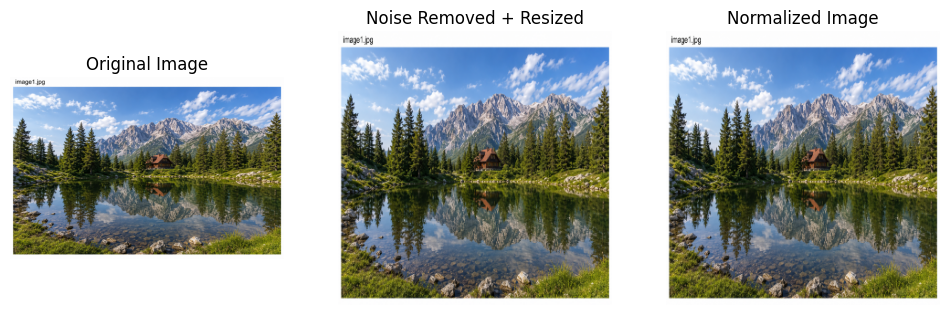

Original size: (1024, 1536, 3)
Resized size: (300, 300, 3)
Normalized range: 0.00392156862745098 to 1.0


In [2]:
#TASK 1

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    noisy = cv2.GaussianBlur(img_rgb, (5, 5), 0)

    resized = cv2.resize(noisy, (300, 300))

    normalized = resized / 255.0

    plt.figure(figsize=(12, 8))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(resized)
    plt.title("Noise Removed + Resized")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(normalized)
    plt.title("Normalized Image")
    plt.axis("off")

    plt.show()

    print("Original size:", img_rgb.shape)
    print("Resized size:", resized.shape)
    print("Normalized range:", normalized.min(), "to", normalized.max())

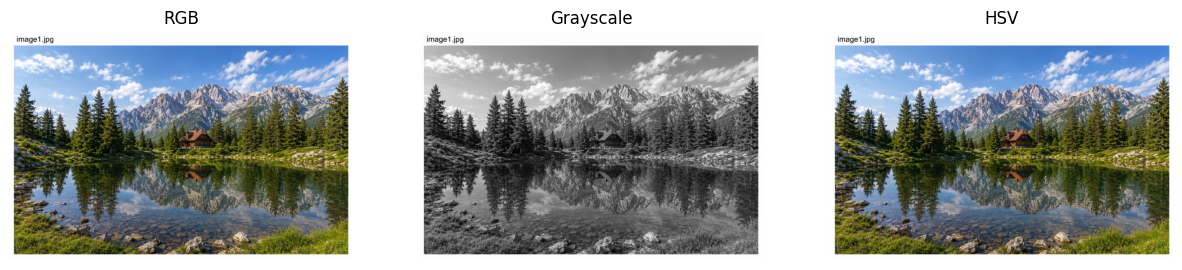

RGB shape: (1024, 1536, 3)
Grayscale shape: (1024, 1536)
HSV shape: (1024, 1536, 3)


In [3]:
#TASK 2

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
    plt.title("HSV")
    plt.axis("off")

    plt.show()

    print("RGB shape:", rgb.shape)
    print("Grayscale shape:", gray.shape)
    print("HSV shape:", hsv.shape)

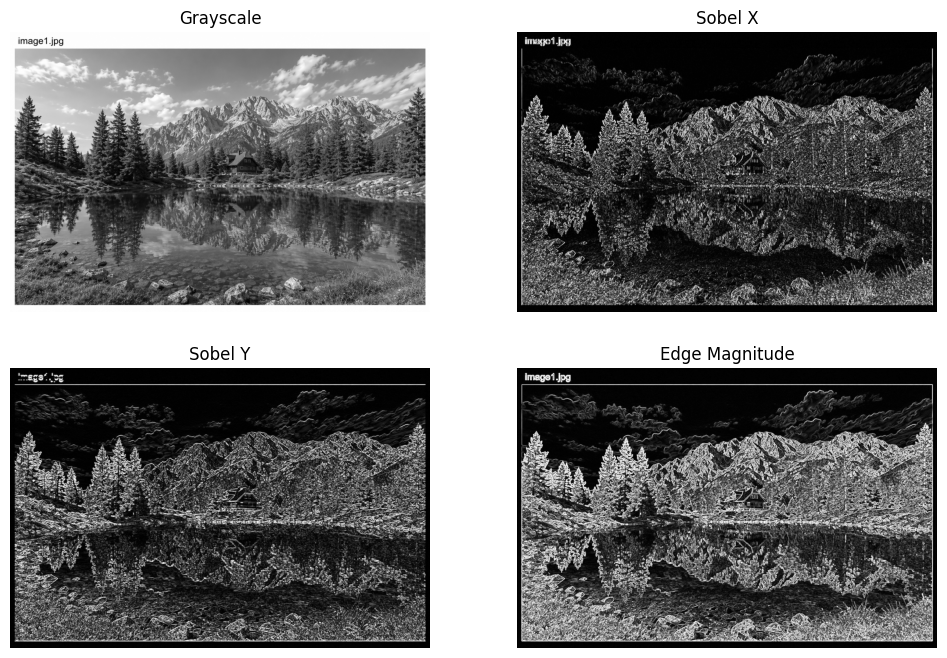

In [5]:
#TASK 3

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = cv2.magnitude(
        cv2.convertScaleAbs(sobel_x).astype("float32"),
        cv2.convertScaleAbs(sobel_y).astype("float32")
    )

    magnitude = cv2.convertScaleAbs(magnitude)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(cv2.convertScaleAbs(sobel_x), cmap="gray")
    plt.title("Sobel X")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(cv2.convertScaleAbs(sobel_y), cmap="gray")
    plt.title("Sobel Y")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(magnitude, cmap="gray")
    plt.title("Edge Magnitude")
    plt.axis("off")

    plt.show()

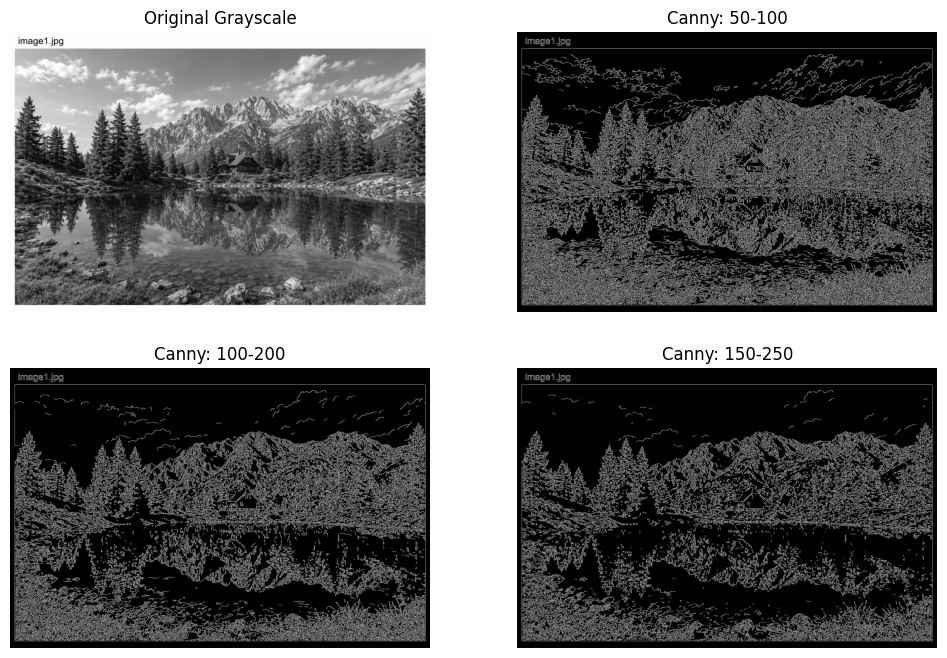

In [7]:
#TASK 4

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges1 = cv2.Canny(gray, 50, 100)
    edges2 = cv2.Canny(gray, 100, 200)
    edges3 = cv2.Canny(gray, 150, 250)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Original Grayscale")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(edges1, cmap="gray")
    plt.title("Canny: 50-100")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(edges2, cmap="gray")
    plt.title("Canny: 100-200")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(edges3, cmap="gray")
    plt.title("Canny: 150-250")
    plt.axis("off")

    plt.show()

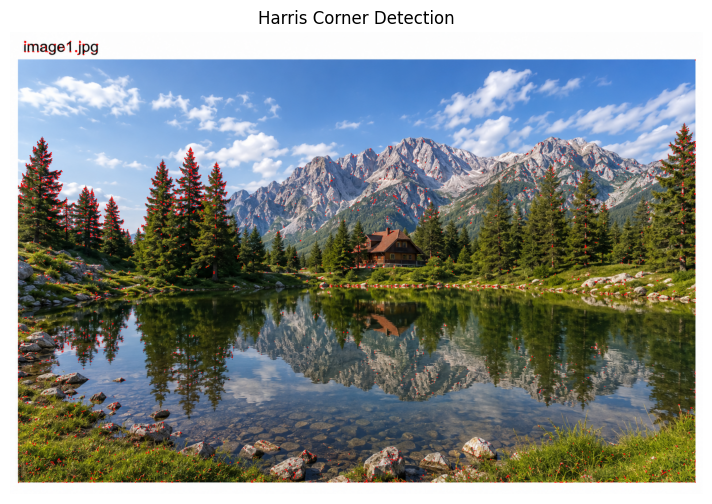

In [10]:
#TASK 5

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    corners = cv2.cornerHarris(gray, 2, 3, 0.04)

    # Fix: Initialize result with a copy of the original image
    result = img.copy()
    result[corners > 0.01 * corners.max()] = [0, 0, 255]

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(result)
    plt.title("Harris Corner Detection")
    plt.axis("off")
    plt.show()

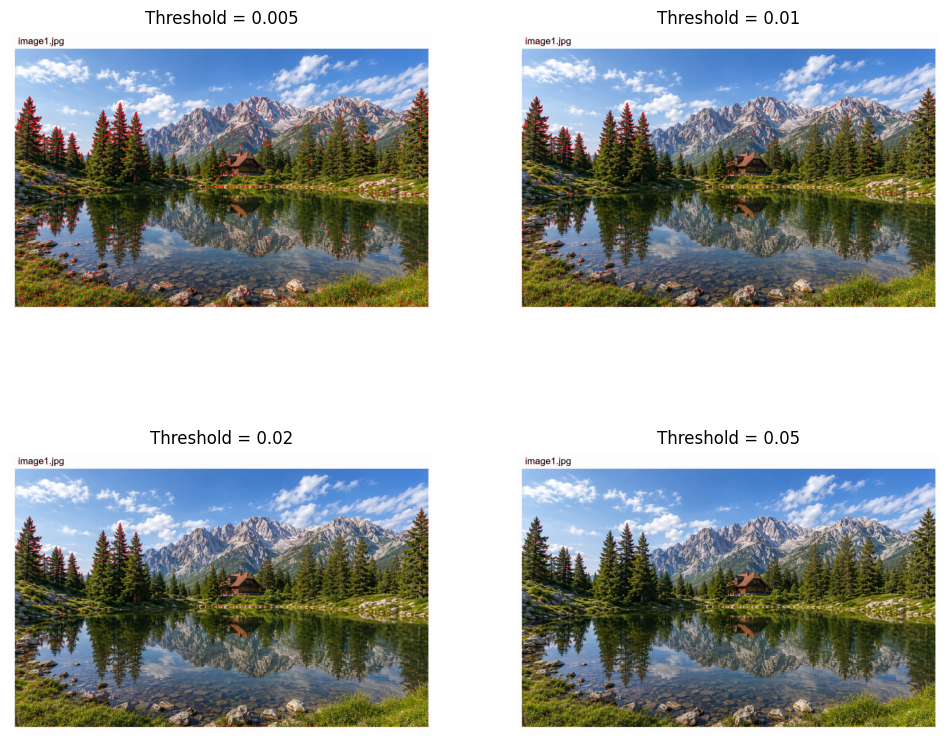

In [12]:
#TASK 6

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_float = np.float32(gray)

    response = cv2.cornerHarris(gray_float, 2, 3, 0.04)

    thresholds = [0.005, 0.01, 0.02, 0.05]

    plt.figure(figsize=(12, 10))

    for i, threshold in enumerate(thresholds):

        result = img.copy()

        result[response > threshold * response.max()] = [0, 0, 255]

        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 2, i + 1)
        plt.imshow(result)
        plt.title("Threshold = " + str(threshold))
        plt.axis("off")

    plt.show()

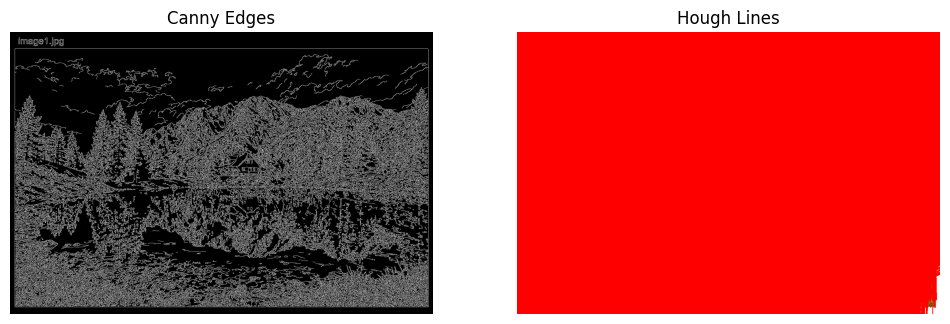

In [13]:
#TASK 7

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150)

    lines = cv2.HoughLines(edges, 1, np.pi / 180, 100)

    result = img.copy()

    if lines is not None:
        for line in lines:
            rho, theta = line[0]

            a = np.cos(theta)
            b = np.sin(theta)

            x0 = a * rho
            y0 = b * rho

            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * a)

            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * a)

            cv2.line(result, (x1, y1), (x2, y2), (0, 0, 255), 2)

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(edges, cmap="gray")
    plt.title("Canny Edges")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title("Hough Lines")
    plt.axis("off")

    plt.show()

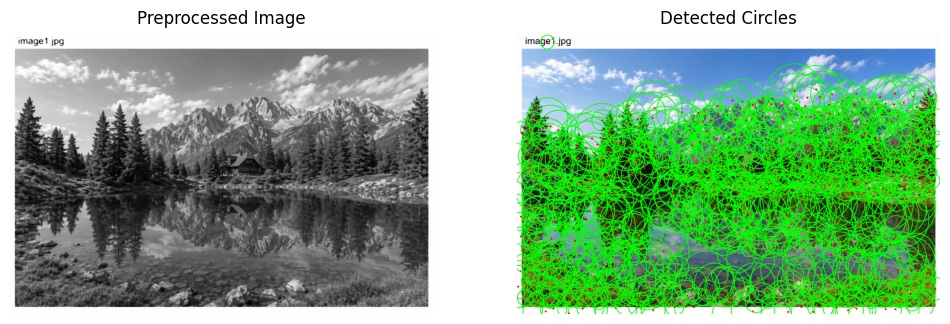

In [14]:
#TASK 8

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.medianBlur(gray, 5)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=30,
        param1=100,
        param2=30,
        minRadius=10,
        maxRadius=100
    )

    result = img.copy()

    if circles is not None:
        circles = np.uint16(np.around(circles))

        for circle in circles[0]:
            x, y, r = circle

            cv2.circle(result, (x, y), r, (0, 255, 0), 2)
            cv2.circle(result, (x, y), 2, (0, 0, 255), 3)

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Preprocessed Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title("Detected Circles")
    plt.axis("off")

    plt.show()

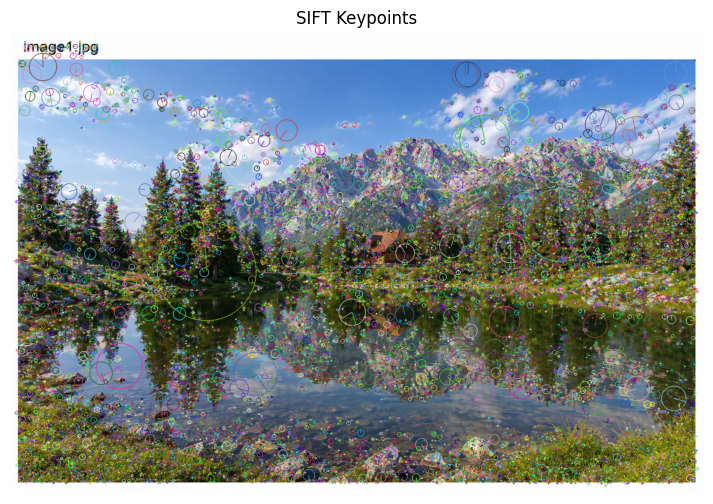

Number of keypoints: 16499
Descriptor shape: (16499, 128)


In [15]:
#TASK 9

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    keypoints, descriptors = sift.detectAndCompute(gray, None)

    result = cv2.drawKeypoints(
        img,
        keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    plt.imshow(result)
    plt.title("SIFT Keypoints")
    plt.axis("off")
    plt.show()

    print("Number of keypoints:", len(keypoints))
    print("Descriptor shape:", descriptors.shape)

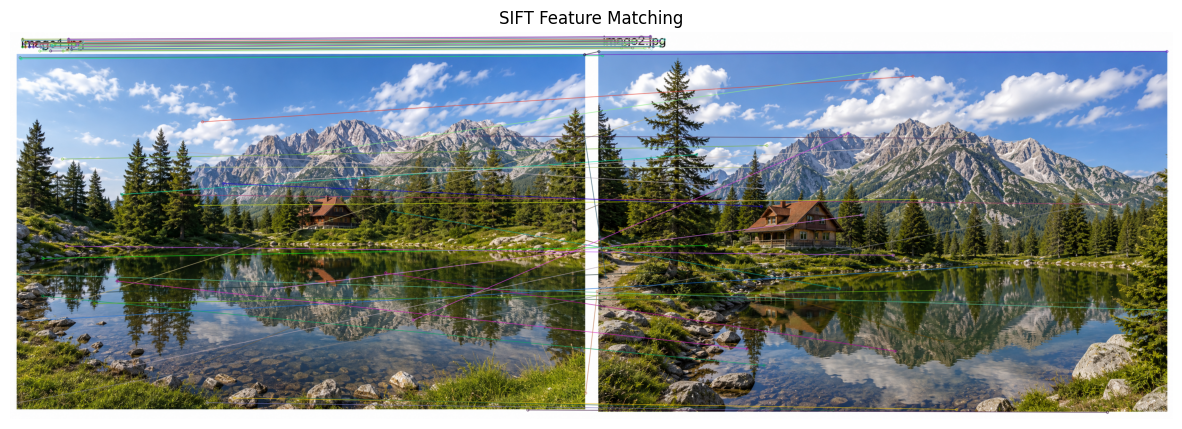

Keypoints in Image 1: 16499
Keypoints in Image 2: 17374
Good matches: 97
Ratio threshold: 0.75


In [16]:
#TASK 10

import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")
img2 = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_40 PM.png")

if img1 is None or img2 is None:
    print("One or both images not found")
else:
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []

    ratio = 0.75

    for m, n in matches:
        if m.distance < ratio * n.distance:
            good_matches.append(m)

    result = cv2.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 7))
    plt.imshow(result)
    plt.title("SIFT Feature Matching")
    plt.axis("off")
    plt.show()

    print("Keypoints in Image 1:", len(kp1))
    print("Keypoints in Image 2:", len(kp2))
    print("Good matches:", len(good_matches))
    print("Ratio threshold:", ratio)

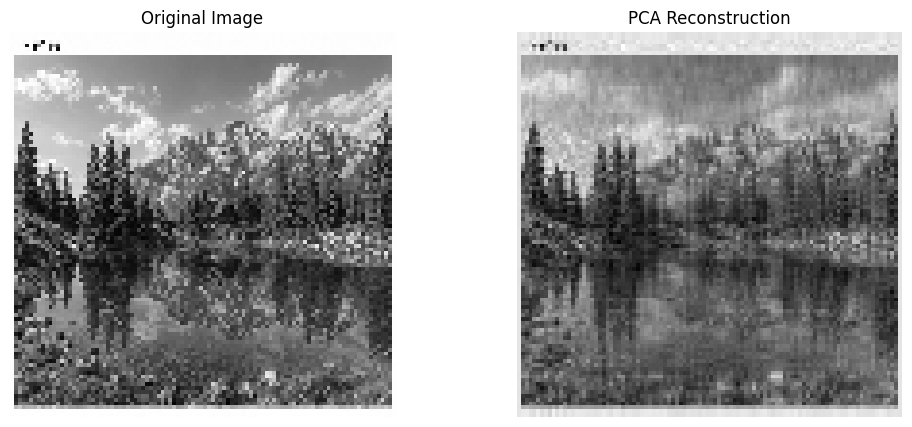

Original dimensions: (100, 100)
Reduced dimensions: (100, 20)
Explained variance: 0.9229849805455902


In [17]:
#TASK 11

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

img = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")

if img is None:
    print("Image not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray, (100, 100))

    data = gray.reshape(100, 100)

    pca = PCA(n_components=20)

    transformed = pca.fit_transform(data)

    reconstructed = pca.inverse_transform(transformed)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed, cmap="gray")
    plt.title("PCA Reconstruction")
    plt.axis("off")

    plt.show()

    print("Original dimensions:", data.shape)
    print("Reduced dimensions:", transformed.shape)

    print(
        "Explained variance:",
        np.sum(pca.explained_variance_ratio_)
    )

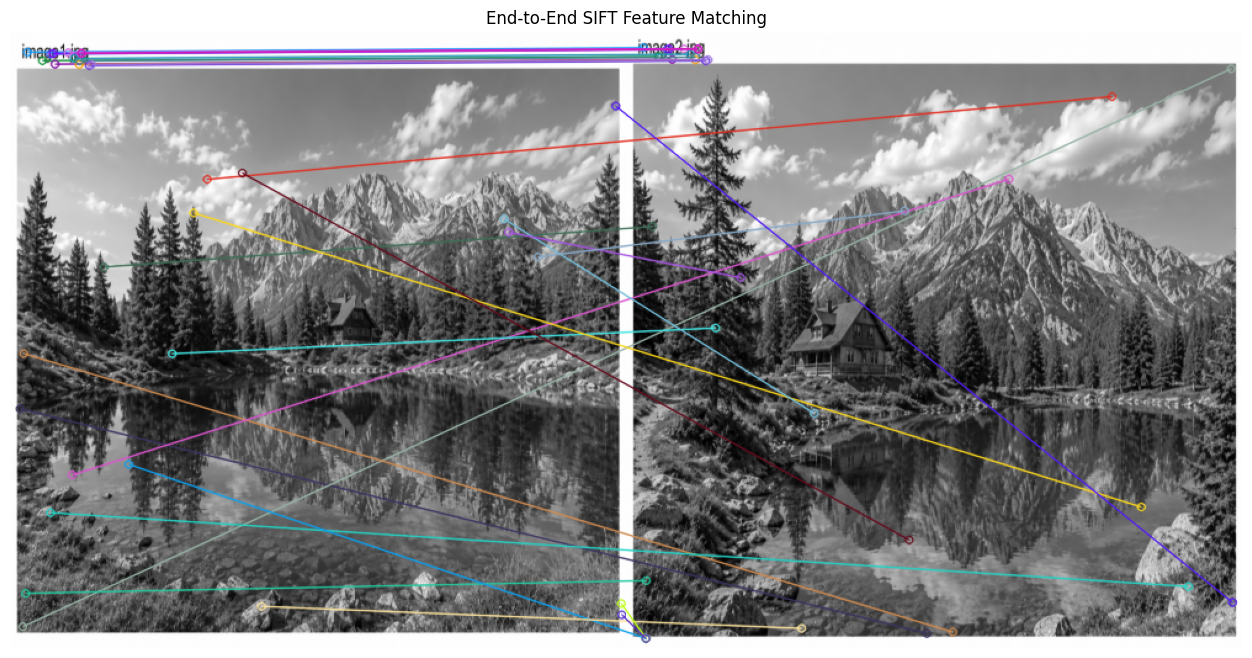

Image 1 keypoints: 3948
Image 2 keypoints: 3976
Total matches: 3948
Good matches: 32


In [18]:
#TASK 12

import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_33 PM.png")
img2 = cv2.imread("/content/ChatGPT Image Aug 8, 2026, 07_18_40 PM.png")

if img1 is None or img2 is None:
    print("One or both images not found")
else:

    # Step 1: Convert to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Step 2: Noise removal
    blur1 = cv2.GaussianBlur(gray1, (5, 5), 0)
    blur2 = cv2.GaussianBlur(gray2, (5, 5), 0)

    # Step 3: Resize
    blur1 = cv2.resize(blur1, (500, 500))
    blur2 = cv2.resize(blur2, (500, 500))

    # Step 4: SIFT feature extraction
    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(blur1, None)
    kp2, des2 = sift.detectAndCompute(blur2, None)

    # Step 5: Feature matching
    bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    # Step 6: Ratio test
    good_matches = []

    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    # Step 7: Draw matched keypoints
    result = cv2.drawMatches(
        blur1,
        kp1,
        blur2,
        kp2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # Visualization
    plt.figure(figsize=(16, 8))

    plt.imshow(result)
    plt.title("End-to-End SIFT Feature Matching")
    plt.axis("off")

    plt.show()

    print("Image 1 keypoints:", len(kp1))
    print("Image 2 keypoints:", len(kp2))
    print("Total matches:", len(matches))
    print("Good matches:", len(good_matches))